In [1]:
import os

In [2]:
!pwd

/Users/abhikchoudhury/Library/CloudStorage/OneDrive-IBM/Badlo/Krish Naik Projects/Kidney_Tumor_Identification_System_Computer_vision/Kidney Tumor Identification System_Abhik/research


In [3]:
os.chdir("../")

In [4]:
!pwd

/Users/abhikchoudhury/Library/CloudStorage/OneDrive-IBM/Badlo/Krish Naik Projects/Kidney_Tumor_Identification_System_Computer_vision/Kidney Tumor Identification System_Abhik


In [ ]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class TrainingConfig:
    root_dir: Path #from config.yaml
    trained_model_path: Path #from config.yaml
    updated_base_model_path: Path #the path is artifacts/prepare basemodel/base_model_updated.h5
    training_data: Path #The training data is in artifacts/data_ingestion. Will be provided when calling, 
    #from get_training_config(self) in this notebook
    params_epochs: int #from params.yaml 
    params_batch_size: int #from params.yaml 
    params_is_augmentation: bool #from params.yaml 
    params_image_size: list #from params.yaml 

#after this cell is run, the code is moved to src/cnnClassifier/entity/configentity.py

In [6]:
#Now the configuration manager
from cnnClassifier.constants import *
from cnnClassifier.utils.common import read_yaml, create_directories
import tensorflow as tf

In [ ]:
#JUST LIKE THE 02_prepare_base_model NOTEBOOK, we are importing the params.yaml and config.yaml path from the cnnclassifier/constants folder.
class ConfigurationManager:
    def __init__(
        self, 
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    
    def get_training_config(self) -> TrainingConfig:
        #basically training gets the compenets of training: from config.yaml()root_dir: and trained_model_path
        training = self.config.training
        prepare_base_model = self.config.prepare_base_model #base model path coming from prepare_base_model of config.yaml
        params = self.params
        #initializing my training data path. The path variables (like unzip_dir) is in config.yaml
        training_data = os.path.join(self.config.data_ingestion.unzip_dir, "kidney-ct-scan-image")
        create_directories([
            Path(training.root_dir)
        ])
#this is the return data, which is exactly the same as defined in entity class TrainingConfig
        training_config = TrainingConfig(
            root_dir=Path(training.root_dir),
            trained_model_path=Path(training.trained_model_path),
            updated_base_model_path=Path(prepare_base_model.updated_base_model_path),
            training_data=Path(training_data),
            params_epochs=params.EPOCHS,
            params_batch_size=params.BATCH_SIZE,
            params_is_augmentation=params.AUGMENTATION,
            params_image_size=params.IMAGE_SIZE
        )

        return training_config
#after this cell is run, the code is moved to src/cnnClassifier/config/configuration.py

In [ ]:
#Now create the components
import os
import urllib.request as request
from zipfile import ZipFile
import tensorflow as tf
import time



### This is the flow diagram of the training class

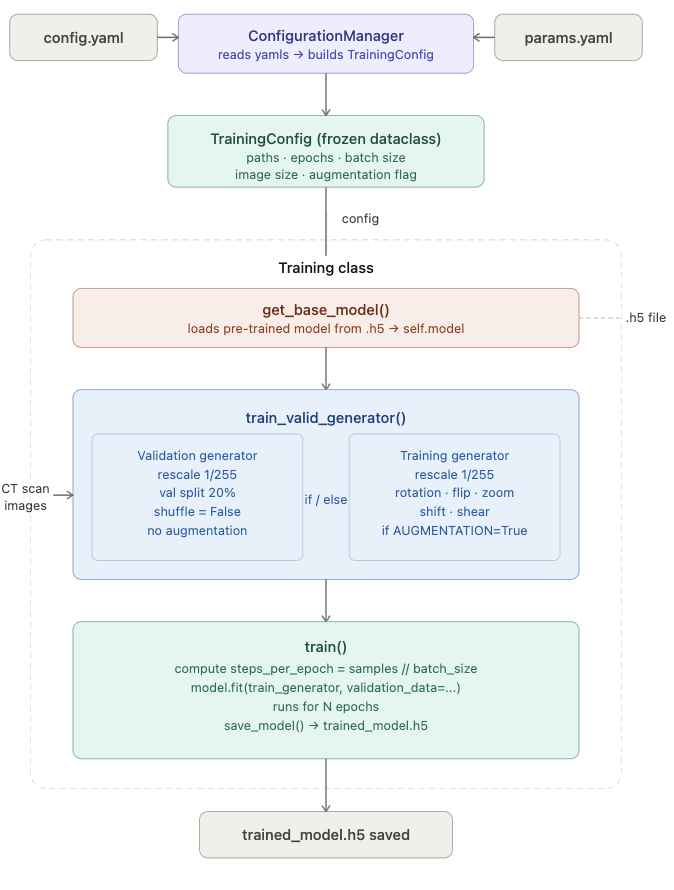



In [ ]:
#initialize training
class Training:
    def __init__(self, config: TrainingConfig):
        self.config = config
    
    def get_base_model(self):
        self.model = tf.keras.models.load_model(
            self.config.updated_base_model_path
        )
    
    def train_valid_generator(self):
#rescale=1./255 — Normalizes pixel values from [0, 255] → [0, 1]. Neural networks train faster and more stably with normalized inputs.
#validation_split=0.20 — 80/20 train/validation split done automatically by Keras.
        datagenerator_kwargs = dict(
            rescale = 1./255,
            validation_split=0.20
        )
#This dict is passed to both flow_from_directory() calls (train & validation), so it defines how images are physically loaded and prepared.
#params_image_size comes from params.yaml and typically looks like: IMAGE_SIZE: [224, 224, 3]  # [Height, Width, Channels].

# The [:-1] slice drops the last element (channels), giving: just Height x Width. 
# it doesn't take channels because channels are determined separately by color_mode parameter (defaults to "rgb" = 3 channels). 
# Passing all 3 values would throw an error.

#Full Batch Gradient Descent     Mini-Batch (this code)      Stochastic (batch=1)
#───────────────────────────     ──────────────────────      ────────────────────
#Uses ALL data per update        Uses 16-32 images           Uses 1 image
#Stable but slow                 Balanced ✓                  Noisy, fast
#Can't fit in GPU RAM            Fits in GPU RAM ✓           Fits easily

#interpolation="bilinear"
#This controls the resizing algorithm when an image's original size ≠ target_size.
#What bilinear interpolation does:
#When scaling an image, new pixel values must be estimated. Bilinear looks at the 4 nearest neighbors and computes a weighted average based on distance:

#Why bilinear specifically for medical imaging?

#Preserves smooth intensity gradients in CT scans (important for tissue boundaries)
#Fast enough for real-time data loading
#Doesn't over-sharpen edges (bicubic can introduce ringing artifacts)

        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation="bilinear"
        )

        valid_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(
            **datagenerator_kwargs
        )
#Why shuffle=False for validation? Because you want deterministic evaluation — shuffling validation data doesn't help 
# learning and makes metric comparison across epochs inconsistent. dataflow_kwargs was defined previously. 
#No augmentation for validation generator, only for training generator
#Validation generator — always plain, never augmented Built first, unconditionally. Takes the validation subset. 
# Shuffle is explicitly False — deterministic order is required for meaningful epoch-to-epoch metric comparison.
        self.valid_generator = valid_datagenerator.flow_from_directory(
            directory=self.config.training_data,
            subset="validation",
            shuffle=False,
            **dataflow_kwargs
        )
#if augmentation is true from Params.yaml, then Augmentation is done, else valid generated is used. 
# #What Augmentation Actually Does? It creates synthetic variations of your real images on-the-fly during training. 
# The model never sees the same version of an image twice, which forces it to learn features, not memorized pixel patterns.
#Original CT Scan
#      │
#      ├──► slightly rotated version    → batch 1
#      ├──► horizontally flipped        → batch 2  
#      ├──► zoomed in slightly          → batch 3
#      └──► shifted left + sheared      → batch 4

#Model sees 4 "different" images, but it's the same scan
        if self.config.params_is_augmentation:
            train_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(
                rotation_range=40, #Randomly rotates the image anywhere between -40° and +40°
                horizontal_flip=True, #Randomly mirrors the image left-to-right with 50% probability
                width_shift_range=0.2, #Randomly translates (slides) the image horizontally/vertically by up to 20% of total width/height
                height_shift_range=0.2,
                shear_range=0.2, #Applies a shear transformation — slants the image along an axis
                zoom_range=0.2, #Randomly zooms in or out by up to 20%
                **datagenerator_kwargs #this was unpacked from earlier
            )
        else:
            train_datagenerator = valid_datagenerator

        self.train_generator = train_datagenerator.flow_from_directory(
            directory=self.config.training_data,
            subset="training",
            shuffle=True,
            **dataflow_kwargs
        )
#the training model is simplified with diagram in the next cell
    @staticmethod
    def save_model(path: Path, model: tf.keras.Model):
        model.save(path)


    def train(self):
        self.steps_per_epoch = self.train_generator.samples // self.train_generator.batch_size
        self.validation_steps = self.valid_generator.samples // self.valid_generator.batch_size

        self.model.fit(
            self.train_generator,
            epochs=self.config.params_epochs,
            steps_per_epoch=self.steps_per_epoch,
            validation_steps=self.validation_steps,
            validation_data=self.valid_generator,
            
        )

        self.save_model(
            path=self.config.trained_model_path,
            model=self.model
        )

#after this cell is run, the code is moved to src/cnnClassifier/components/model_training.py

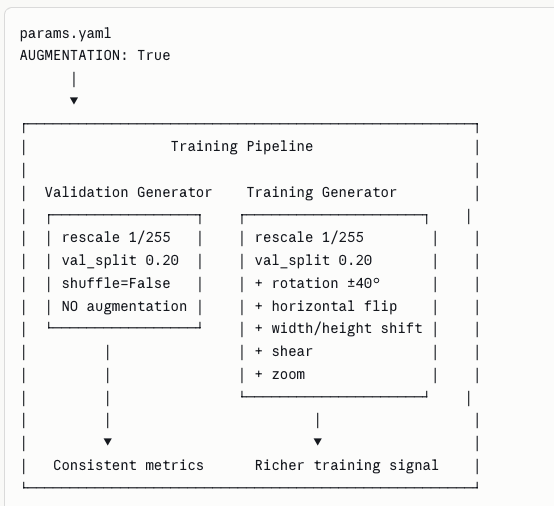

Here are the details of train_valid_generator method

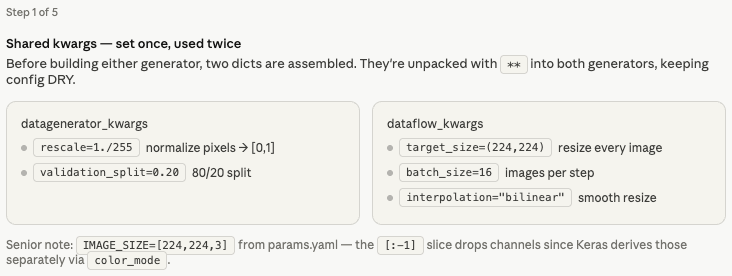
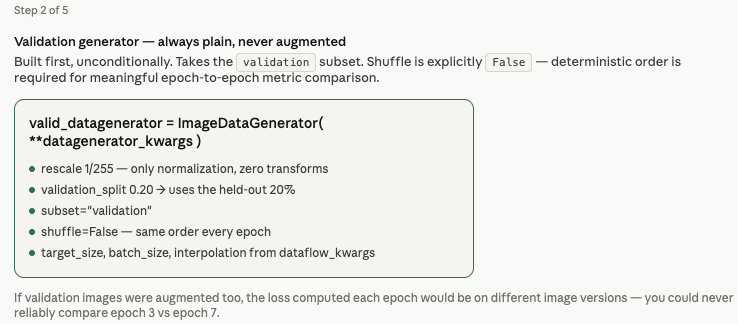
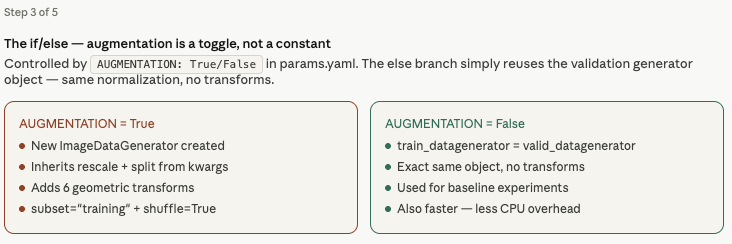
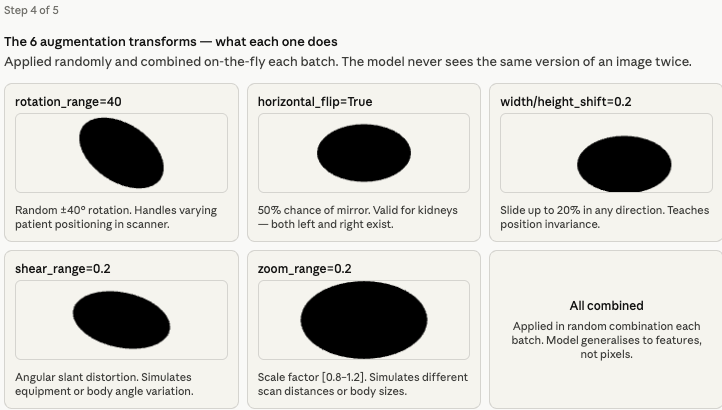
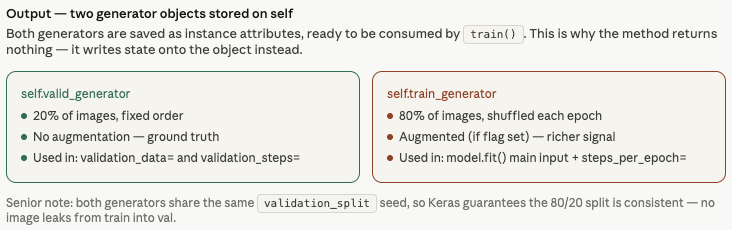

In [ ]:
try:
    config = ConfigurationManager()
    

    training_config = config.get_training_config()
    training = Training(config=training_config)
    training.get_base_model()
    training.train_valid_generator()
    training.train()
    
except Exception as e:
    raise e

#after this cell is run, the code is moved to src/cnnClassifier/pipeline/stage_03_model_training.py

[2026-05-06 14:29:40,601: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-05-06 14:29:40,621: INFO: common: yaml file: params.yaml loaded successfully]
[2026-05-06 14:29:40,625: INFO: common: created directory at: artifacts]
[2026-05-06 14:29:40,630: INFO: common: created directory at: artifacts/training]
Found 93 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
23/23 [==============================] - 80s 3s/step - loss: 12.1607 - accuracy: 0.5478 - val_loss: 8.3938 - val_accuracy: 0.4375


/opt/anaconda3/envs/kidney/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
